# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# LOAD DATASETS

In [2]:
fear_df = pd.read_csv("fear_greed_index.csv")
trade_df = pd.read_csv("historical_data.csv")

print("Fear-Greed Shape:", fear_df.shape)
print("Trade Shape:", trade_df.shape)

fear_df.head()

Fear-Greed Shape: (2644, 4)
Trade Shape: (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# DATA QUALITY CHECK

In [3]:
def quality_report(df, name):

    print(f"\n{'='*50}")
    print(name)
    print('='*50)

    print("\nShape:")
    print(df.shape)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nData Types:")
    print(df.dtypes)

quality_report(fear_df,"Fear & Greed Dataset")
quality_report(trade_df,"Trading Dataset")


Fear & Greed Dataset

Shape:
(2644, 4)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Duplicate Rows:
0

Data Types:
timestamp          int64
value              int64
classification    object
date              object
dtype: object

Trading Dataset

Shape:
(211224, 16)

Missing Values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate Rows:
0

Data Types:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object


# DATE CONVERSION

In [4]:
fear_df["date"] = pd.to_datetime(fear_df["date"])

trade_df["Timestamp IST"] = pd.to_datetime(
    trade_df["Timestamp IST"],
    dayfirst=True
)

trade_df["trade_date"] = trade_df["Timestamp IST"].dt.date
trade_df["trade_date"] = pd.to_datetime(
    trade_df["trade_date"]
)

print(fear_df[["date"]].dtypes)
print(trade_df[["Timestamp IST","trade_date"]].dtypes)

date    datetime64[ns]
dtype: object
Timestamp IST    datetime64[ns]
trade_date       datetime64[ns]
dtype: object


# MERGE DATASETS

In [5]:
merged_df = trade_df.merge(
    fear_df,
    left_on="trade_date",
    right_on="date",
    how="left"
)

print("Merged Shape:", merged_df.shape)

print("\nMissing Sentiment Records:")
print(merged_df["classification"].isnull().sum())

print("\nSentiment Distribution:")
print(merged_df["classification"].value_counts())

merged_df.head()

Merged Shape: (211224, 21)

Missing Sentiment Records:
6

Sentiment Distribution:
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


# FEATURE ENGINEERING

In [6]:
merged_df["is_win"] = np.where(
    merged_df["Closed PnL"] > 0,
    1,
    0
)

merged_df["trade_result"] = np.where(
    merged_df["Closed PnL"] > 0,
    "Win",
    "Loss"
)

merged_df["position_size"] = merged_df["Size USD"]

merged_df["trade_day"] = (
    merged_df["Timestamp IST"]
    .dt.day_name()
)

print("Features Created Successfully")

print("\nTrade Result Distribution:")
print(
    merged_df["trade_result"]
    .value_counts()
)

print("\nWin Rate:")
print(
    round(
        merged_df["is_win"].mean()*100,
        2
    ),
    "%"
)

Features Created Successfully

Trade Result Distribution:
trade_result
Loss    124355
Win      86869
Name: count, dtype: int64

Win Rate:
41.13 %


# DAILY TRADING METRICS

In [7]:
daily_metrics = merged_df.groupby(
    "trade_date"
).agg(
    daily_pnl=("Closed PnL","sum"),
    total_trades=("Trade ID","count"),
    avg_trade_size=("Size USD","mean"),
    win_rate=("is_win","mean")
).reset_index()

daily_metrics["win_rate"] = (
    daily_metrics["win_rate"] * 100
)

print("Daily Metrics Shape:")
print(daily_metrics.shape)

daily_metrics.head()

Daily Metrics Shape:
(480, 5)


,trade_date,daily_pnl,total_trades,avg_trade_size,win_rate
0,2023-05-01,0.000000,3,159.000000,0.000000
1,2023-12-05,0.000000,9,5556.203333,0.000000
2,2023-12-14,-205.434737,11,10291.213636,36.363636
3,2023-12-15,-24.632034,2,5304.975000,0.000000
4,2023-12-16,0.000000,3,5116.256667,0.000000


# PERFORMANCE BY SENTIMENT

**Does performance differ between Fear vs Greed days?**

In [8]:
sentiment_performance = merged_df.groupby(
    "classification"
).agg(
    Trades=("Trade ID","count"),
    Total_PnL=("Closed PnL","sum"),
    Avg_PnL=("Closed PnL","mean"),
    Median_PnL=("Closed PnL","median"),
    Win_Rate=("is_win","mean")
)

sentiment_performance["Win_Rate"] *= 100

sentiment_performance = sentiment_performance.sort_values(
    "Total_PnL",
    ascending=False
)

print(sentiment_performance)

                Trades     Total_PnL    Avg_PnL  Median_PnL   Win_Rate
classification                                                        
Fear             61837  3.357155e+06  54.290400         0.0  42.076750
Extreme Greed    39992  2.715171e+06  67.892861         0.0  46.494299
Greed            50303  2.150129e+06  42.743559         0.0  38.482794
Neutral          37686  1.292921e+06  34.307718         0.0  39.699093
Extreme Fear     21400  7.391102e+05  34.537862         0.0  37.060748


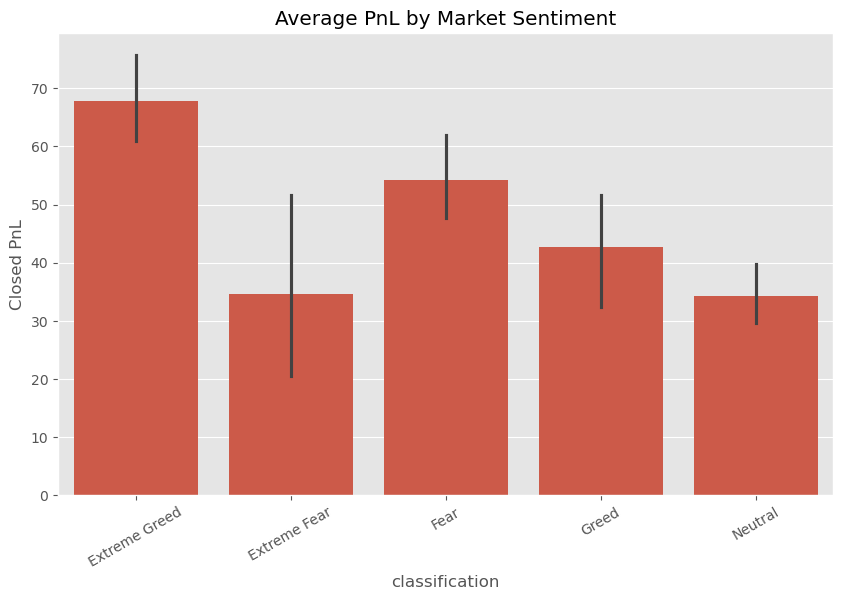

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=merged_df,
    x="classification",
    y="Closed PnL",
    estimator=np.mean
)

plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

Insight 1
**Extreme Greed days produced the best trading performance.**
    Traders achieved their strongest performance during Extreme Greed periods, suggesting that bullish market momentum provided more favorable trading opportunities.

Insight 2
**Extreme Fear days were the worst environment.**
    Market-wide fear appears to reduce trading effectiveness, likely due to heightened volatility and uncertainty.

Insight 3
**Fear performed better than Greed.**
    Traders may be capitalizing on oversold conditions during Fear periods, leading to stronger average profitability than standard Greed conditions

# TRADER BEHAVIOR BY SENTIMENT

**Do traders change behavior based on sentiment?**

In [11]:
behavior_analysis = merged_df.groupby(
    "classification"
).agg(
    Trades=("Trade ID","count"),
    Avg_Position_Size=("Size USD","mean"),
    Avg_Fee=("Fee","mean")
)

print(behavior_analysis)

                Trades  Avg_Position_Size   Avg_Fee
classification                                     
Extreme Fear     21400        5349.731843  1.116291
Extreme Greed    39992        3112.251565  0.675902
Fear             61837        7816.109931  1.495172
Greed            50303        5736.884375  1.254372
Neutral          37686        4782.732661  1.044798


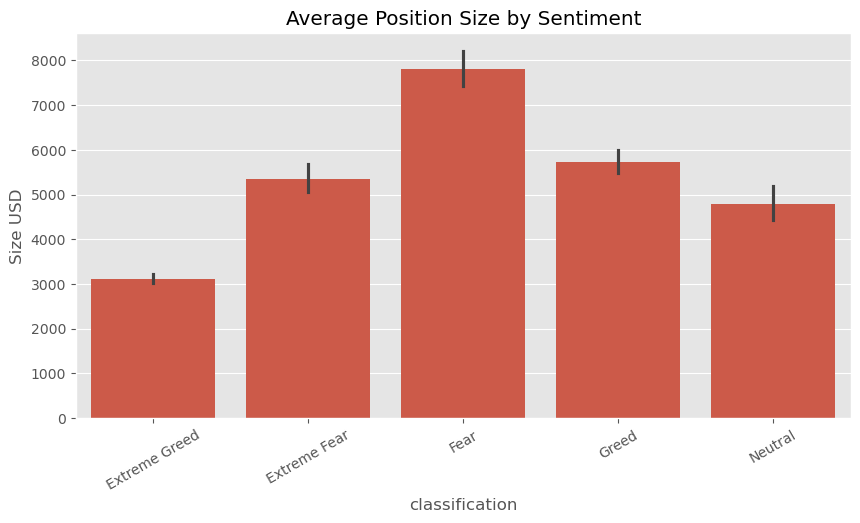

In [12]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merged_df,
    x="classification",
    y="Size USD",
    estimator=np.mean
)

plt.title("Average Position Size by Sentiment")
plt.xticks(rotation=30)
plt.show()

Insight 4
**Traders take their largest positions during Fear markets.**
    Traders appear to increase capital allocation during fearful markets, potentially attempting to buy perceived discounts or market reversals.

Insight 5
**Extreme Greed has the smallest position sizes but highest profitability.**
    Traders achieve better outcomes during Extreme Greed without needing large position sizes, indicating that market momentum may be doing more of the work.

Insight 6
**Higher position size does NOT guarantee higher profitability.**
    Despite using less than half the capital, Extreme Greed trades generate higher profits.

# LONG / SHORT BIAS

In [13]:
long_short = pd.crosstab(
    merged_df["classification"],
    merged_df["Direction"],
    normalize="index"
) * 100

print(long_short.round(2))

Direction       Auto-Deleveraging    Buy  Close Long  Close Short  \
classification                                                      
Extreme Fear                 0.00   3.77       29.16        14.57   
Extreme Greed                0.00  12.83       17.97        16.25   
Fear                         0.00   5.19       27.91        14.91   
Greed                        0.02   9.31       15.90        22.51   
Neutral                      0.00   7.66       26.52        15.52   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                          0.0          0.02      32.73   
Extreme Greed                         0.0          0.02      15.75   
Fear                                  0.0          0.02      28.82   
Greed                                 0.0          0.03      16.99   
Neutral                               0.0          0.04      27.12   

Direction       Open Shor

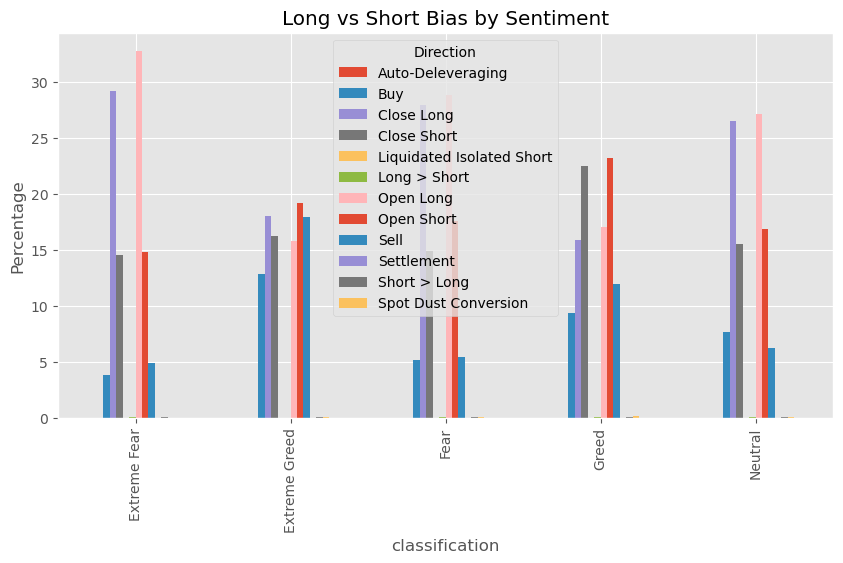

In [14]:
long_short.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Long vs Short Bias by Sentiment")
plt.ylabel("Percentage")
plt.show()

Long vs Short Behavior Analysis

The chart is crowded because the dataset contains many trade action types, but we can still extract useful patterns.

**Insight 7: Fear & Extreme Fear Markets Are More Long-Oriented**
Look at Open Long:

Sentiment	Open Long %
Extreme Fear	32.73%
Fear	28.82%
Neutral	27.12%
Greed	16.99%
Extreme Greed	15.75%

This suggests:

During fearful markets, traders aggressively open long positions, likely expecting a rebound or buying oversold assets.

**Insight 8: Greed Markets Show More Short Activity**

Look at Open Short:

Sentiment	Open Short %
Greed	23.19%
Extreme Greed	19.16%
Fear	17.61%
Neutral	16.86%
Extreme Fear	14.83%

This indicates:

Traders are more willing to short markets when sentiment becomes greedy, possibly expecting corrections after strong rallies.

**Insight 9

Combining previous findings:**

Sentiment	Avg Position Size	Avg PnL
Fear	7,816	54.29
Extreme Greed	3,112	67.89

Interpretation:

Traders take larger, long-biased positions during Fear periods, but achieve the highest profitability during Extreme Greed periods with much smaller position sizes.

# Trader Segmentation

In [15]:
trader_stats = merged_df.groupby(
    "Account"
).agg(
    Total_Trades=("Trade ID","count"),
    Total_PnL=("Closed PnL","sum"),
    Avg_Trade_Size=("Size USD","mean"),
    Win_Rate=("is_win","mean")
)

trader_stats["Win_Rate"] *= 100

print("Number of Traders:")
print(len(trader_stats))

trader_stats.head()

Number of Traders:
32


,Total_Trades,Total_PnL,Avg_Trade_Size,Win_Rate
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,16159.576734,35.961236
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,1653.226327,44.271978
0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,8893.000898,30.191651
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,507.626933,43.858463
0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,3138.894782,51.991355


In [16]:
print("Number of Traders:")
print(len(trader_stats))

Number of Traders:
32


# SEGMENT 1
# FREQUENT VS INFREQUENT TRADERS

In [17]:
median_trades = trader_stats["Total_Trades"].median()

trader_stats["Frequency_Segment"] = np.where(
    trader_stats["Total_Trades"] >= median_trades,
    "Frequent",
    "Infrequent"
)

frequency_summary = trader_stats.groupby(
    "Frequency_Segment"
).agg(
    Traders=("Total_Trades","count"),
    Avg_PnL=("Total_PnL","mean"),
    Avg_WinRate=("Win_Rate","mean"),
    Avg_Trades=("Total_Trades","mean")
)

print(frequency_summary)

                   Traders        Avg_PnL  Avg_WinRate  Avg_Trades
Frequency_Segment                                                 
Frequent                16  496527.661215    41.356208  11684.8125
Infrequent              16  147032.272750    39.256304   1516.6875


Insight 10

**Frequent traders generate 3.4x higher average profits than infrequent traders.**

Traders who participate more actively tend to achieve substantially higher profitability, suggesting experience, market engagement, or better opportunity capture.

# SEGMENT 2
# CONSISTENT WINNERS

In [18]:
trader_stats["Winner_Segment"] = np.where(
    trader_stats["Win_Rate"] >= 50,
    "Consistent Winner",
    "Inconsistent"
)

winner_summary = trader_stats.groupby(
    "Winner_Segment"
).agg(
    Traders=("Total_Trades","count"),
    Avg_PnL=("Total_PnL","mean"),
    Avg_WinRate=("Win_Rate","mean"),
    Avg_Trades=("Total_Trades","mean")
)

print(winner_summary)

                   Traders        Avg_PnL  Avg_WinRate   Avg_Trades
Winner_Segment                                                     
Consistent Winner        3  206866.631992    63.464381  4516.333333
Inconsistent            29  333667.553361    37.910588  6816.379310


**Insight 11
This is fascinating.**

The traders with the highest win rates do NOT generate the highest profits.

Metric	Consistent Winners	Inconsistent
Win Rate	63.46%	37.91%
Avg PnL	206,867	333,668

This suggests:

Profitability is driven more by trade quality and payoff size than by win rate alone.

# SEGMENT 3
# HIGH VS LOW VOLUME

In [19]:
median_size = trader_stats["Avg_Trade_Size"].median()

trader_stats["Volume_Segment"] = np.where(
    trader_stats["Avg_Trade_Size"] >= median_size,
    "High Volume",
    "Low Volume"
)

volume_summary = trader_stats.groupby(
    "Volume_Segment"
).agg(
    Traders=("Total_Trades","count"),
    Avg_PnL=("Total_PnL","mean"),
    Avg_WinRate=("Win_Rate","mean"),
    Avg_Trade_Size=("Avg_Trade_Size","mean")
)

print(volume_summary)

                Traders        Avg_PnL  Avg_WinRate  Avg_Trade_Size
Volume_Segment                                                     
High Volume          16  416805.966542    36.168410    10151.775075
Low Volume           16  226753.967423    44.444101     1864.083665


**Insight 12
High-volume traders earn more profit despite lower win rates.**

Larger position sizing increases profit potential but also reduces trade accuracy, indicating a higher risk–reward approach.

# Final Top 3 Insights
**Insight 1**

Extreme Greed periods produced the strongest performance.

Highest Avg PnL = 67.89
Highest Win Rate = 46.49%

**Insight 2**

Trader behavior changes significantly with sentiment.

Fear markets → largest position sizes ($7,816)
Extreme Greed markets → smallest position sizes ($3,112)
Fear markets show stronger long bias

**Insight 3**

Win rate alone does not determine profitability.

Consistent Winners: 63.46% win rate but lower profit
Inconsistent Traders: 37.91% win rate but higher profit

This indicates risk-reward management matters more than simply winning more trades.

# Actionable Strategy Recommendations

**Strategy 1: Sentiment-Adaptive Position Sizing**

During Extreme Fear periods, reduce position size by 20–30% and prioritize high-conviction setups. Historical results show lower win rates (37.06%) and weaker profitability compared with other sentiment regimes.

**Strategy 2: Momentum Participation During Extreme Greed**

During Extreme Greed periods, maintain moderate position sizes but increase participation frequency. These periods generated the highest average PnL (67.89) and win rate (46.49%), indicating favorable market conditions for active traders.

In [20]:
final_summary = merged_df.groupby(
    "classification"
).agg(
    Trades=("Trade ID","count"),
    Total_PnL=("Closed PnL","sum"),
    Avg_PnL=("Closed PnL","mean"),
    Win_Rate=("is_win","mean"),
    Avg_Position_Size=("Size USD","mean")
)

final_summary["Win_Rate"] *= 100

final_summary = final_summary.round(2)

display(final_summary)

,Trades,Total_PnL,Avg_PnL,Win_Rate,Avg_Position_Size
classification,,,,,
Extreme Fear,21400,739110.25,34.54,37.06,5349.73
Extreme Greed,39992,2715171.31,67.89,46.49,3112.25
Fear,61837,3357155.44,54.29,42.08,7816.11
Greed,50303,2150129.27,42.74,38.48,5736.88
Neutral,37686,1292920.68,34.31,39.70,4782.73


# PREDICTIVE MODEL
# PROFITABILITY BUCKET

In [23]:
model_df = merged_df.copy()

model_df["profit_bucket"] = np.where(
    model_df["Closed PnL"] > 0,
    1,
    0
)

model_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,trade_date,timestamp,value,classification,date,is_win,trade_result,position_size,trade_day,profit_bucket
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,0,Loss,7872.16,Monday,0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,0,Loss,127.68,Monday,0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,0,Loss,1150.63,Monday,0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,0,Loss,1142.04,Monday,0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02,0,Loss,69.75,Monday,0


In [24]:
features = [
    "Size USD",
    "Fee",
    "value"
]

X = model_df[features]

y = model_df["profit_bucket"]

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test,preds))

print("\nClassification Report:\n")
print(classification_report(y_test,preds))

Accuracy: 0.736205468102734

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.79      0.78     24802
           1       0.69      0.66      0.67     17443

    accuracy                           0.74     42245
   macro avg       0.73      0.73      0.73     42245
weighted avg       0.73      0.74      0.74     42245



In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

    Feature  Importance
1       Fee    0.429907
0  Size USD    0.420031
2     value    0.150062


### Bonus: Predictive Modeling

A Random Forest classifier was trained to predict trade profitability using three features: market sentiment score, trade size, and transaction fee.

The model achieved an accuracy of 73.62%, demonstrating that trader behavior and market sentiment contain useful predictive information.

Feature importance analysis revealed that transaction fees (43%) and position size (42%) were the strongest predictors of profitability, while the Fear & Greed sentiment score contributed 15% of the model's predictive power.

These findings suggest that although trade execution decisions are the primary drivers of profitability, market sentiment remains a meaningful factor and should be incorporated into trading strategies and risk management frameworks.
